In [1]:
from prophet import Prophet
import sys
sys.path.append('../files')
from sklearn.metrics import mean_squared_error
from files.functions import *
from files.API_KEYS import *

In [2]:
fullDataPath('BTC')

'data/BTC_df.csv'

In [6]:
# Preprocess data and set it up
data = pd.read_csv(f'../data/{COIN}_df.csv')
data['time'] = pd.to_datetime(data['time'], errors='coerce')
data = data.dropna(subset=['time'])
data['date'] = data['time'].dt.date
daily_data = dataSetup(data, trainingColPath='../files/training_columns.txt')
daily_data

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,low,high,open,close,gradient
time,,,,,,,,,,,,,
2015-07-20,268.225208,299.188792,71.0,0.000000,782.883420,-3.817129e+06,283.615714,4417.348637,277.37,280.00,277.98,280.00,0.00
2015-07-21,266.070954,300.106046,71.0,0.000000,4943.559434,-3.817912e+06,285.645714,5228.512882,276.85,281.27,279.96,277.32,-2.68
2015-07-22,263.804410,301.155590,71.0,0.000000,4687.909383,-3.812968e+06,288.280000,5345.414337,275.01,278.54,277.33,277.89,0.57
2015-07-23,263.024045,301.345955,71.0,0.000000,5306.919575,-3.817656e+06,290.037143,5421.928306,276.28,279.75,277.96,277.39,-0.50
2015-07-24,261.412051,301.912949,71.0,0.000000,7362.469083,-3.812349e+06,291.622857,5397.937160,276.43,291.52,277.23,289.12,11.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-15,103144.495964,123587.093036,70.0,0.000627,23726.313561,-3.335235e+04,118689.097143,0.000000,115697.37,119973.30,119863.71,117781.64,-2082.07
2025-07-16,103144.495964,123587.093036,68.0,-5.189416,9250.986426,-9.626039e+03,118689.097143,0.000000,117033.23,120134.80,117781.63,118681.68,900.04
2025-07-17,103144.495964,123587.093036,70.0,9.995038,8360.351309,-3.750526e+02,118689.097143,0.000000,117469.00,120998.76,118681.67,119273.69,592.01


## Normalize Data

In [13]:
scaler = StandardScaler()
target_scaler = StandardScaler()
daily_data_normalized = daily_data.copy()
for col in daily_data_normalized.columns:
    if col not in ['time', 'close']:
        daily_data_normalized[col] = scaler.fit_transform(daily_data_normalized[[col]])
    else:
        daily_data_normalized[col] = target_scaler.fit_transform(daily_data_normalized[[col]])
daily_data_normalized


,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,low,high,open,close,gradient
time,,,,,,,,,,,,,
2015-07-20,-0.882445,-0.921143,0.267001,-0.013960,-1.146472,-1.991674,-0.903383,-1.124557,-0.899304,-0.906262,-0.903339,-0.903160,-0.029557
2015-07-21,-0.882528,-0.921113,0.267001,-0.013960,-0.789617,-1.992348,-0.903310,-1.030743,-0.899323,-0.906217,-0.903268,-0.903256,-0.032013
2015-07-22,-0.882616,-0.921079,0.267001,-0.013960,-0.811544,-1.988093,-0.903216,-1.017222,-0.899391,-0.906313,-0.903362,-0.903235,-0.029034
2015-07-23,-0.882646,-0.921073,0.267001,-0.013960,-0.758452,-1.992128,-0.903153,-1.008373,-0.899344,-0.906270,-0.903339,-0.903253,-0.030015
2015-07-24,-0.882708,-0.921054,0.267001,-0.013960,-0.582150,-1.987560,-0.903097,-1.011148,-0.899338,-0.905856,-0.903366,-0.902833,-0.018804
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-15,3.090989,3.119352,0.148113,-0.011975,0.821354,1.265488,3.326634,-1.635444,3.329854,3.307798,3.390163,3.309616,-1.938060
2025-07-16,3.090989,3.119352,-0.089662,-16.445410,-0.420175,1.285912,3.326634,-1.635444,3.378802,3.313484,3.315410,3.341885,0.795454
2025-07-17,3.090989,3.119352,0.148113,31.633717,-0.496563,1.293876,3.326634,-1.635444,3.394769,3.343902,3.347724,3.363111,0.513102


16:01:46 - cmdstanpy - INFO - Chain [1] start processing
16:01:47 - cmdstanpy - INFO - Chain [1] done processing


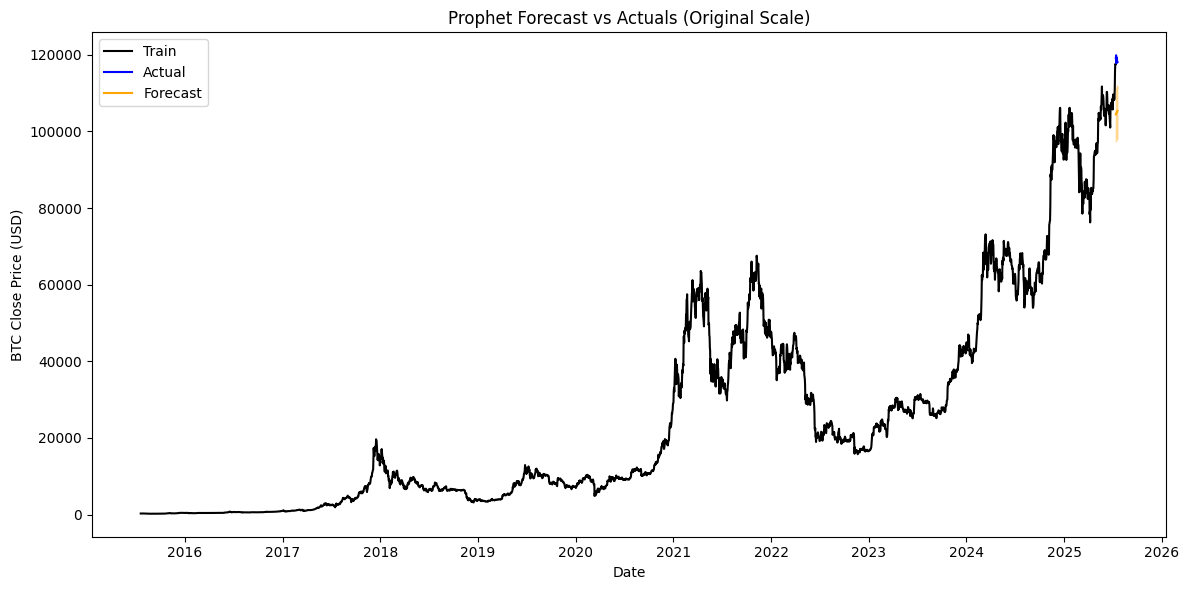

RMSE (Original Scale): $13803.22
Relative RMSE: 11.63%


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [14]:
# Split data into train/test
train = daily_data_normalized.iloc[:-TEST_DAYS]
test = daily_data_normalized.iloc[-TEST_DAYS:]

# Prepare training data for Prophet
train_prophet = train.reset_index().rename(columns={'time': 'ds', 'close': 'y'})
m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m.add_seasonality(name='weekly', period=7, fourier_order=3)
m.fit(train_prophet)

# Create future dataframe that includes the test period
future = m.make_future_dataframe(periods=TEST_DAYS, freq='D')

# Generate forecast
df_forecast = m.predict(future)
test_prophet = test.reset_index().rename(columns={'time': 'ds', 'close': 'y'})
fcst_test = df_forecast.set_index('ds').loc[test_prophet['ds'], ['yhat','yhat_lower','yhat_upper']]

# Inverse transform the predictions back to original scale
fcst_test_original = fcst_test.copy()
fcst_test_original[['yhat', 'yhat_lower', 'yhat_upper']] = target_scaler.inverse_transform(fcst_test[['yhat', 'yhat_lower', 'yhat_upper']])

# Inverse transform the test data back to original scale
test_prophet_original = test_prophet.copy()
test_prophet_original['y'] = target_scaler.inverse_transform(test_prophet[['y']])

# Inverse transform the training data back to original scale for plotting
train_prophet_original = train_prophet.copy()
train_prophet_original['y'] = target_scaler.inverse_transform(train_prophet[['y']])

# Plot results with original scale
plt.figure(figsize=(12,6))
plt.plot(train_prophet_original['ds'], train_prophet_original['y'], label='Train', color='black')
plt.plot(test_prophet_original['ds'], test_prophet_original['y'], label='Actual', color='blue')
plt.plot(fcst_test_original.index, fcst_test_original['yhat'], label='Forecast', color='orange')
plt.fill_between(fcst_test_original.index,
                 fcst_test_original['yhat_lower'],
                 fcst_test_original['yhat_upper'],
                 color='orange', alpha=0.3)
plt.title('Prophet Forecast vs Actuals (Original Scale)')
plt.xlabel('Date'); plt.ylabel('BTC Close Price (USD)')
plt.legend(); plt.grid(False); plt.tight_layout()
plt.show()

# Calculate RMSE on original scale
mse = mean_squared_error(test_prophet_original['y'], fcst_test_original['yhat'], squared=False)
print(f'RMSE (Original Scale): ${mse:.2f}')
print(f'Relative RMSE: {mse / test_prophet_original["y"].mean() * 100:.2f}%')


16:07:35 - cmdstanpy - INFO - Chain [1] start processing
16:07:36 - cmdstanpy - INFO - Chain [1] done processing


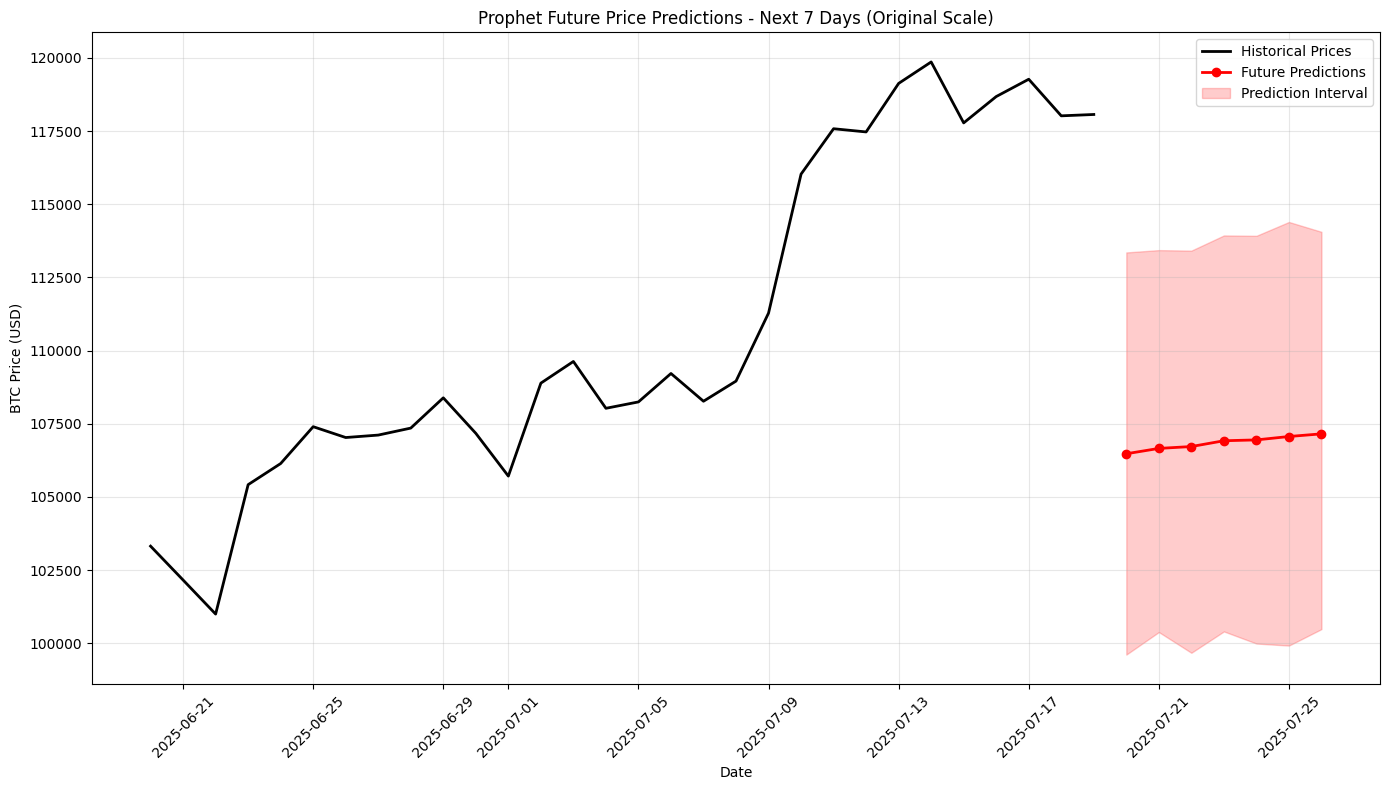

In [18]:
# === Future Predictions on Full Dataset ===
# Retrain Prophet model on the entire dataset
full_prophet_data = daily_data_normalized.reset_index().rename(columns={'time': 'ds', 'close': 'y'})

# Create and fit new model on full dataset
m_full = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m_full.add_seasonality(name='weekly', period=7, fourier_order=3)
m_full.fit(full_prophet_data)

# Generate future predictions for the next 30 days
future_full = m_full.make_future_dataframe(periods=TEST_DAYS, freq='D')
forecast_full = m_full.predict(future_full)

# Extract only the future predictions (last 30 days)
future_predictions = forecast_full.tail(TEST_DAYS)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
future_predictions['ds'] = pd.to_datetime(future_predictions['ds'])

# Inverse transform the future predictions back to original scale
future_predictions_original = future_predictions.copy()
future_predictions_original[['yhat', 'yhat_lower', 'yhat_upper']] = target_scaler.inverse_transform(
    future_predictions[['yhat', 'yhat_lower', 'yhat_upper']]
)

# Rename columns and round to 2 decimal places
future_predictions_original = future_predictions_original.rename(columns={
    'ds': 'date',
    'yhat': 'predicted_price',
    'yhat_lower': 'lower_bound',
    'yhat_upper': 'upper_bound'
})

price_columns = ['predicted_price', 'lower_bound', 'upper_bound']
future_predictions_original[price_columns] = future_predictions_original[price_columns].round(2)

# Save predictions to file
predictions_dir = '../predictions/BTC'
os.makedirs(predictions_dir, exist_ok=True)
predictions_file = os.path.join(predictions_dir, 'prophet_future_predictions.csv')
future_predictions_final = future_predictions_original.copy()
future_predictions_final.rename(columns={'predicted_price': 'predictions'}, inplace=True)
future_predictions_final.to_csv(predictions_file, index=False)

# Plot future predictions with original scale data
plt.figure(figsize=(14, 8))
# Plot historical data (last 60 days for context) - inverse transformed
historical_context = full_prophet_data.tail(30).copy()
historical_context['y_original'] = target_scaler.inverse_transform(historical_context[['y']])
plt.plot(historical_context['ds'], historical_context['y_original'], label='Historical Prices', color='black', linewidth=2)

# Plot future predictions
plt.plot(future_predictions_original['date'], future_predictions_original['predicted_price'],
         label='Future Predictions', color='red', linewidth=2, marker='o')
plt.fill_between(future_predictions_original['date'],
                 future_predictions_original['lower_bound'],
                 future_predictions_original['upper_bound'],
                 color='red', alpha=0.2, label='Prediction Interval')

plt.title(f'Prophet Future Price Predictions - Next {TEST_DAYS} Days (Original Scale)')
plt.xlabel('Date')
plt.ylabel('BTC Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()